In [19]:

import os
import cv2
import numpy as np
import pandas as pd
from collections import Counter

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Number of training samples: 39209


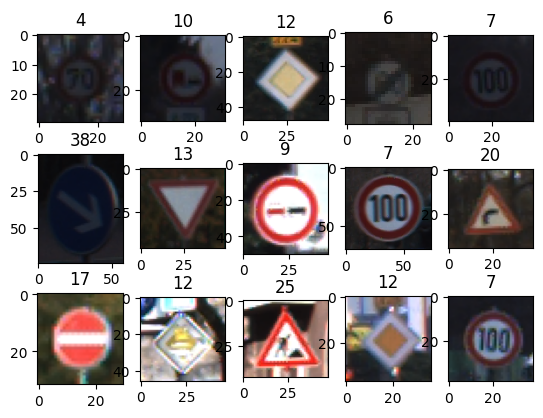

In [4]:
# Load the training labels
root = '/Users/dmytro/Downloads/gtsrb-german-traffic-sign' # Path to the dataset location, e.g., '/data/janko/dataset/GTSRB'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples = len(data)
print(f'Number of training samples: {num_samples}')

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

Number of classes: 43


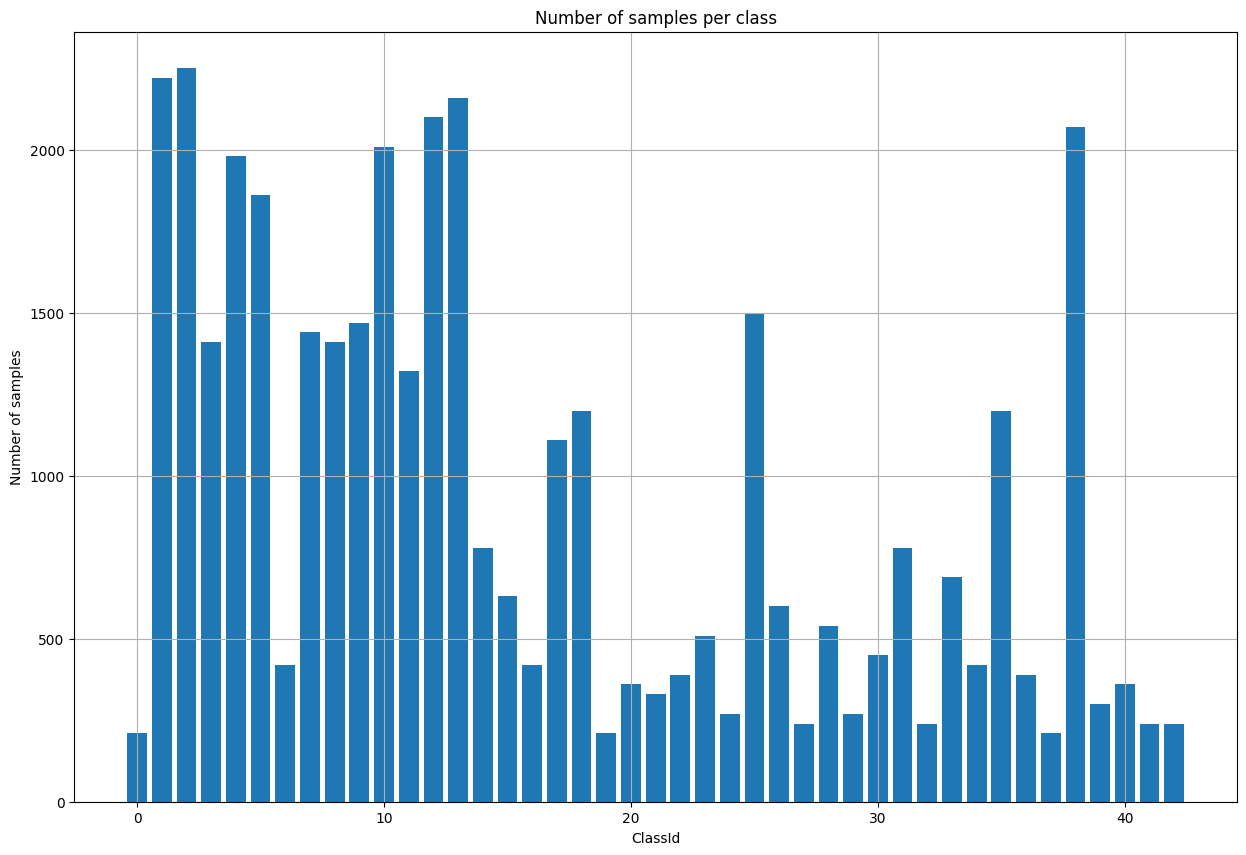

In [21]:
ids = data['ClassId'].unique()
print(f'Number of classes: {len(ids)}')

c = Counter(data['ClassId'])

plt.bar(c.keys(), c.values())
plt.grid(True)
plt.xlabel('ClassId')
plt.ylabel('Number of samples')
plt.title('Number of samples per class')
plt.show()

>Do you consider the dataset to be balanced? If so, why? If not, why?
Датасет не сбалансирован, потому что на графике можно увидеть что количество семплов для разных класов сильно отличается. Например 19й (небезопасный поворот на лево) и 39й(обьезд препятствия слева) классы знаков имеют значительно меньше семплов по сравнению с другими. Так же исследовав Train папку я как и предпологал заметил что семплы "нарезаны" из видео покадрово, то есть можно увидеть как машина приближалась к знаку. Такая же ситуация с небольшим количетвом семполов для класов 41, 42 и еще части класов/знаков. Так же я заметил что размер/расширение семплов тоже меняется, от мальенкого до большого что тоже необходимо учитывать при обучении модели, я думаю.

>Are there any classes that are (significantly) over-represented or under-represeneted?
Уже частично ответил в предидущем вопросе, но повторюсь. Классы 19 и 39 являются значительно недопредставленными по сравнению с другими классами. Знаки 4.7 (клас 38) обьезд препятствия справа и Знаки 3.29(класс 1 и класс 2) ограничение скорости, имеют намного больше семплов. Думаю такая разница обусловлена реальностью размещения знаков на дорогах. Какие-то знаки встречаються постоянно, а какие-то являются екзотическими и встречаются редко где-то в определенных местах.

>Ниже сделал анализ датасета по распределению размеров и яркости изображений. Распределение семплов смещено в сторону семплов маленького размера и низкой яркости, думаю что это нужно учитывать при обучении модели, то есть нужно будет добавить с помощью аугментации больше семплов что бы сбалансировать датасет по этим параметрам ну и заресайзить большие семплы до среднего размера. 

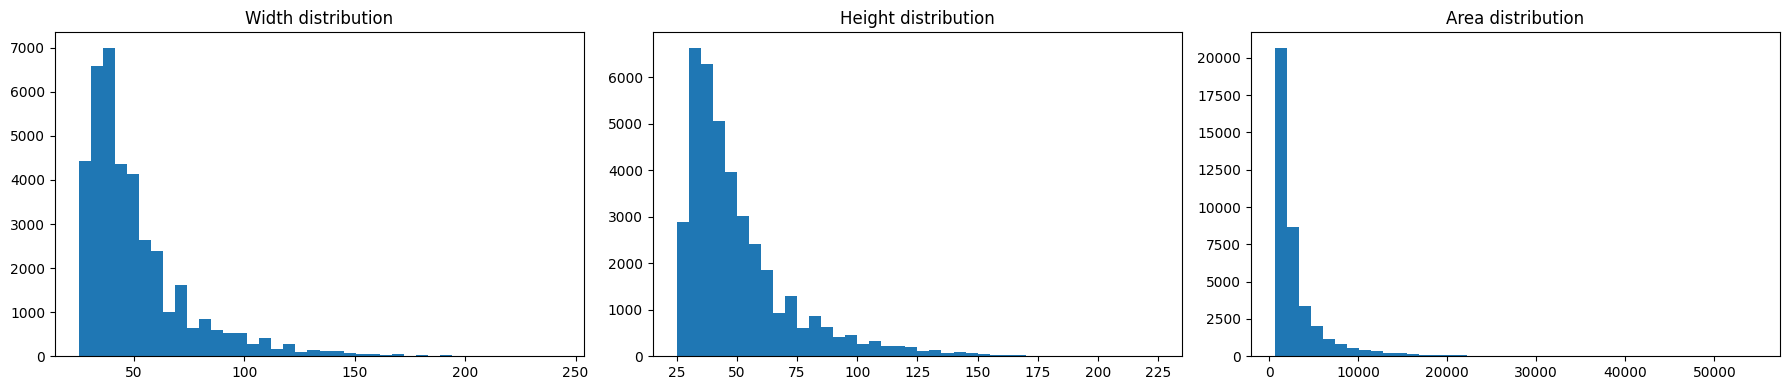

In [11]:
# calculate width, height, area and aspect ratio of each image
if 'Width' not in data.columns or 'Height' not in data.columns:
    widths, heights = [], []
    # iterate through all images and calculate width and height
    for p in data['Path']:
        img = cv2.imread(os.path.join(root, p))
        if img is None:
            print(f'Warning: Could not read image at path {p}')
            widths.append(0)
            heights.append(0)
            continue
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)
    data['Width'] = widths
    data['Height'] = heights

# calculate area and aspect ratio
data['Area'] = data['Width'] * data['Height']
data['AspectRatio'] = data['Width'] / data['Height']

# plot histograms of width, height and area
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].hist(data['Width'], bins=40)
ax[0].set_title('Width distribution')
ax[1].hist(data['Height'], bins=40)
ax[1].set_title('Height distribution')
ax[2].hist(data['Area'], bins=40)
ax[2].set_title('Area distribution')
plt.tight_layout()
plt.show()

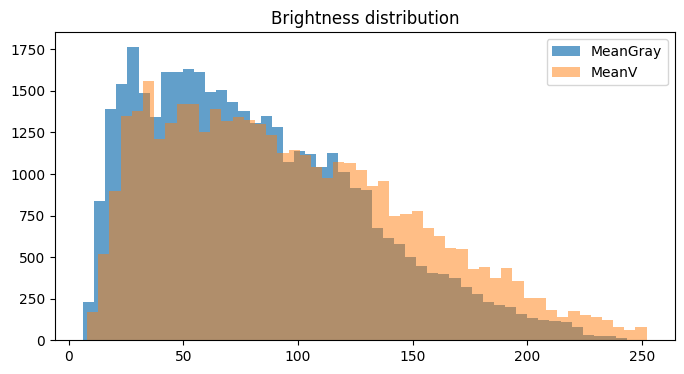

In [17]:
mean_gray, std_gray, mean_v = [], [], []

# iterate through all images and calculate mean and std of gray and mean of V channel in HSV
for p in data['Path']:
    img_bgr = cv2.imread(os.path.join(root, p))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # calculate mean and std of gray and mean of V channel in HSV
    mean_gray.append(gray.mean())
    std_gray.append(gray.std())
    mean_v.append(hsv[:, :, 2].mean())

# add mean and std of gray and mean of V channel in HSV to data
data['MeanGray'] = mean_gray
data['StdGray'] = std_gray
data['MeanV'] = mean_v

plt.figure(figsize=(8,4))
plt.hist(data['MeanGray'], bins=50, alpha=0.7, label='MeanGray')
plt.hist(data['MeanV'], bins=50, alpha=0.5, label='MeanV')
plt.legend()
plt.title('Brightness distribution')
plt.show()